# Lavirint u tami
### Navigacija kroz delimično opažen prostor putem POMDP pristupa
**Autor:** Nikola Velemir SV8/2022

**Projekat:** Implementacija POMDP rešenja za navigaciju agenta u lavirintu sa nepotpunim informacijama


## Problem
Omogućiti agentu da se navigira kroz lavirint gde:
- Nema potpune informacije o okruženju
- Opažanja su ograničena i šumovita
- Potrebno je donošenje odluka u uslovima nesigurnosti

### Rešenje
Implementacija **POMDP** (Partially Observable Markov Decision Process) modela sa **POMCP** (Partially Observable Monte Carlo Planning) algoritmom.


## Šta je POMDP model?

**POMDP** (engl. *Partially Observable Markov Decision Process*) predstavlja matematički okvir za modelovanje **odlučivanja u uslovima nesigurnosti**, gde agent nema potpunu informaciju o stanju okruženja.
Za razliku od klasičnog **Markovljevog procesa odlučivanja (MDP)**, gde se stanje sistema uvek zna, kod POMDP-a agent može samo **delimično da opaža** svet kroz šumovite i ograničene senzorske podatke.

---


### Formalna definicija

POMDP se formalno definiše kao sedmorka:

**{POMDP}** = (S, A, T, R, $\Omega$, O, $\gamma$)


gde su:

| Oznaka | Značenje |
|:--------|:-----------|
| **S** | Skup svih mogućih **stanja** okruženja. (npr. pozicije agenta u lavirintu) |
| **A** | Skup mogućih **akcija** koje agent može da izvrši. (npr. gore, dole, levo, desno) |
| **T(s, a, s′)** | **Model prelaza** – verovatnoća da agent pređe iz stanja *s* u stanje *s′* nakon akcije *a*. |
| **R(s, a)** | **Funkcija nagrade** – vrednost (pozitivna ili negativna) koju agent dobija za akciju *a* u stanju *s*. |
| **Ω** | Skup mogućih **opažanja** koje agent može da primi iz okruženja. |
| **O(s′, a, o)** | **Model opažanja** – verovatnoća da agent dobije opažanje *o* nakon što je prešao u novo stanje *s′* i izvršio akciju *a*. |
| **γ** | **Discount faktor (0 ≤ γ ≤ 1)** – određuje koliko agent vrednuje buduće nagrade u odnosu na trenutne. |

---


### Belief State – Verovanje agenta o svetu

Pošto agent ne zna tačno u kom se stanju nalazi, on održava **distribuciju verovanja nad mogućim stanjima** — tzv. *belief state* (oznaka **b(s)**).

Formalno:

$$
b(s) = P(s_t = s \mid o_{1:t}, a_{1:t-1})
$$

- Na početku epizode, agent ima inicijalno verovanje o tome gde se nalazi.
- Nakon svake akcije i dobijenog opažanja, on ažurira svoje belief stanje koristeći **Bayesovo pravilo**:

$$
b'(s') = \eta \, O(s', a, o) \sum_{s \in S} T(s, a, s') \, b(s)
$$
- gde je \( $\eta$ \) faktor normalizacije koji osigurava da zbir verovatnoća bude 1.

#### 🔹 Ažuriranje belief-a:
Kada agent izvrši akciju $a$ i dobije opažanje $o$, belief se ažurira po Bayesovom pravilu:

$$
b'(s') = \eta \, P(o \mid s', a) \sum_{s} P(s' \mid s, a) \, b(s)
$$

gde je:
- $P(s' \mid s, a)$ – tranzicioni model,
- $P(o \mid s', a)$ – model opažanja,
- $\eta$ – normalizaciona konstanta.

---


# POMCP – Partially Observable Monte Carlo Planning

**POMCP** (Partially Observable Monte Carlo Planning) je algoritam koji kombinuje **Monte Carlo Tree Search (MCTS)** sa **simulacijom belief state-a**.

Umesto da eksplicitno održava celu distribuciju stanja (što je skupo), POMCP koristi **distribuciju verovatnoce** koji predstavlja belief.
Svaka simulacija:
1. Nasumično uzorkuje jedno moguće stvarno stanje iz belief-a.
2. Izvršava simuliranu akciju i opažanje.
3. Ažurira vrednosti čvorova u stablu na osnovu ishoda.

Odluka o sledećoj akciji se donosi pomoću **UCB (Upper Confidence Bound)** formule:


$UCB(s, a)$ = $Q(s,a)$ + c $\sqrt{\frac{\ln N(s)}{N(s,a)}}$

gde je:
- $Q(s,a)$  – procenjena srednja nagrada akcije,
- $N(s)$  – broj poseta čvoru,
- $N(s,a)$  – broj puta kada je akcija `a` izabrana u stanju `s`,
- c – konstanta istraživanja (`exploration_const`).

Ova metoda omogućava agentu da:
- istražuje nepoznate akcije (eksploracija),
- koristi do sada naučeno (eksploatacija),
- donosi odluke u **realnom vremenu** bez potpunog modela sveta.

---


## Setup i Import biblioteka

Prvo je neophodno kreirati **.venv**.

```
python -m venv .venv

#Windows
.\venv\Scripts\activate

#Linux
source .venv/bin/activate
```

Potom instalirati potrebne bibliteke sadrzane u **requirements.txt**.

```pip install -r requirements.txt```


**requirements.txt** sadrzi:

```
attrs==25.4.0
contourpy==1.3.3
cycler==0.12.1
Cython==3.1.4
fonttools==4.60.1
jsonschema==4.25.1
jsonschema-specifications==2025.9.1
kiwisolver==1.4.9
matplotlib==3.10.6
mpmath==1.3.0
numpy==2.3.3
packaging==25.0
pandas==2.3.3
pillow==11.3.0
pomdp-py==1.3.5.1
pyparsing==3.2.5
python-dateutil==2.9.0.post0
pytz==2025.2
referencing==0.36.2
rpds-py==0.27.1
scipy==1.16.2
seaborn==0.13.2
six==1.17.0
sympy==1.14.0
tk==0.1.0
tqdm==4.67.1
tzdata==2025.2
```

Kljucna za implementaciju ovog konkretnog problema je eksperimentalna biblioteka **pompd-py**, u kojoj je definisan osnovni template za modelovanje ovakvih problema.

# Pokretanje rešenja

Pod `src` folderom, main fajl pokreće GUI, odakle je moguće učitati primere problema, pokrenuti vizuelizaciju lavirinta, pratiti kretanje agent, pregledati heatmap. Promena okruženja kroz interfejs nije podržana, stoga neophodno je promeniti parametre u zadatom JSON fajlu tabele/problema, i kliknuti "`Reload board`" dugme.

# Komponente POMDP Modela

Svaka komponenta modela je definisana u razlicitom python fajlu, prateći template **pomdp-py** klasa. Implementacija projekta je izdeljenja tako da prati terminologiju POMDP problema (domen, model, agent, solver, problem) - smernice postavljene od autora **pomdp-py**.

## Klasa State

U okviru **POMDP** modela, klasa `MazeState` predstavlja **stanje agenta u lavirintu**.
Ona čuva trenutnu poziciju agenta, dimenzije lavirinta i lokacije objekata od interesa (npr. novčića).

---

### 🔹 Svrha

Klasa `MazeState` enkapsulira:

- Trenutnu **poziciju agenta** `(x, y)`.
- Dimenzije lavirinta: `width` i `height`.
- Skup **preostalih novčića** ili drugih interaktivnih objekata (`coins`).
- Omogućava agentu da izračuna **sledeće stanje** nakon izvršenja akcije.

---

### 🔹 Komponente

| Atribut | Opis |
|---------|-----|
| `x` | Trenutna X koordinata agenta u lavirintu. |
| `y` | Trenutna Y koordinata agenta u lavirintu. |
| `width` | Širina lavirinta. |
| `height` | Visina lavirinta. |
| `coins` | Skup koordinata preostalih novčića koje agent može pokupiti. |

---


In [1]:
from IPython.display import Code, display
display(Code(filename="../src/domain/maze_state.py", language="python"))


from __future__ import annotations

from typing import Tuple, Set

import pomdp_py
from src.domain.action import Action


class MazeState(pomdp_py.State):
    def __init__(self, x: int, y: int, width: int, height: int, coins: Set[Tuple[int, int]] = None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.x = x
        self.y = y
        self.width = width
        self.height = height
        self.coins = coins if coins else set()

    def get_next_state(self, action: Action) -> MazeState:
        """Return the next MazeState given an action, bounded by width/height."""
        x, y = self.x, self.y

        if action.name == Action.UP:
            y = max(0, y - 1)
        elif action.name == Action.DOWN:
            y = min(self.height - 1, y + 1)
        elif action.name == Action.LEFT:
            x = max(0, x - 1)
        elif action.name == Action.RIGHT:
            x = min(self.width - 1, x + 1)

        new_coins = set(self.coins)
        if (x,y) in new_coins:
            new_coins.remove((x,y))

        return MazeState(x, y, self.width, self.height,coins=new_coins)

    def __hash__(self):
        return hash((self.x, self.y, self.width, self.height))

    def __eq__(self, other):
        return (
                isinstance(other, MazeState)
                and self.x == other.x
                and self.y == other.y
                and self.width == other.width
                and self.height == other.height
                and self.coins == other.coins
        )

    def __str__(self):
        return f"State({self.x}, {self.y})"

    def __repr__(self):
        return f"State({self.x}, {self.y}, coins={self.coins})"

## Klasa Action

U okviru **POMDP** modela, klasa `Action` predstavlja **akcije koje agent može izvršiti** u okruženju.
Agent se kreće kroz lavirint u **četiri osnovna pravca kretanja**: gore, dole, levo i desno.

---

### 🔹 Svrha

Klasa `Action` enkapsulira:

- Validaciju akcije koju agent želi da izvrši.
- Daje jasnu i čitljivu reprezentaciju akcija za ispis i debagovanje.

---

### 🔹 Komponente

| Atribut / Metoda | Opis |
|-----------------|-----|
| `UP`, `DOWN`, `LEFT`, `RIGHT` | Konstantne vrednosti koje predstavljaju dozvoljene akcije. |
| `__init__(self, name)` | Konstruktor koji proverava da li je prosleđena akcija validna. Ako nije, baca `ValueError`. |
| `name` | Ime akcije (string), npr. `"up"`, `"down"`, `"left"`, `"right"`. |

---


In [2]:
from IPython.display import Code, display
display(Code(filename="../src/domain/action.py", language="python"))

import pomdp_py


class Action(pomdp_py.Action):
    UP = "up"
    DOWN = "down"
    LEFT = "left"
    RIGHT = "right"

    def __init__(self, name: str):
        if name not in [self.UP, self.DOWN, self.LEFT, self.RIGHT]:
            raise ValueError(f"Invalid action: {name}")
        self.name = name

    def __hash__(self):
        return hash(self.name)

    def __eq__(self, other):
        if isinstance(other, Action):
            return self.name == other.name
        return False

    def __str__(self):
        return self.name

    def __repr__(self):
        return "Action(%s)" % self.name

## Klasa Observation

U okviru **POMDP** modela, klasa `Observation` predstavlja **informaciju koju agent prima iz okruženja** nakon izvršene akcije.
U ovom implementiranom primeru, agent opaža stanje **u četiri osnovna pravca**: sever (north), jug (south), istok (east) i zapad (west).

---

### 🔹 Svrha

Klasa `Observation` enkapsulira:

- Šta agent **pokusava da oseti iz okruzenja u svakom od četiri pravca**:
  - `'clear'` – slobodna ćelija
  - `'wall'` – prepreka
  - `'trap'` – zamka
  - `'hole'` - rupa
  - `'goal'` – cilj
- Omogućava agentu da **ažurira svoje belief stanje** i donosi odluke u delimično opaženom prostoru.

---

### 🔹 Ključne komponente

| Atribut | Opis |
|---------|------|
| `north` | Stanje ćelije na severu od agenta. |
| `south` | Stanje ćelije na jugu od agenta. |
| `east`  | Stanje ćelije na istoku od agenta. |
| `west`  | Stanje ćelije na zapadu od agenta. |

---

### 🔹 Uloga u POMDP

1. Nakon što agent izvrši akciju, okruženje generiše instancu `Observation`.
2. Agent koristi opažanje da **ažurira svoje belief stanje** koristeći model opažanja \(O(s', a, o)\).
3. Opažanja u četiri pravca pomažu agentu da **planira sledeću optimalnu akciju**, čak i kada ne poznaje kompletno stanje lavirinta.

---

In [3]:
from IPython.display import Code, display
display(Code(filename="../src/domain/observation.py", language="python"))

import pomdp_py


class Observation(pomdp_py.Observation):
    def __init__(self, north=None, south=None, east=None, west=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # What agent senses in each direction
        self.north = north  # 'clear', 'wall', 'trap', 'goal','hole'
        self.south = south
        self.east = east
        self.west = west

    def __hash__(self):
        return hash((self.north, self.south, self.east, self.west))

    def __eq__(self, other):
        if isinstance(other, Observation):
            return \
                    self.north == other.north and \
                    self.south == other.south and \
                    self.east == other.east and \
                    self.west == other.west
        return False

    def __str__(self):
        return f'(N:{str(self.north)}, S:{str(self.south)}, E:{str(self.east)}, W:{str(self.west)})'

    def __repr__(self):
        return f'Observation(N:{self.north}, S:{self.south}, E:{self.east}, W:{self.west})'

## Klasa TransitionModel

U okviru **POMDP** modela, klasa `TransitionModel` definiše **verovatnoće prelaza između stanja** u lavirintu kada agent izvrši neku akciju.
Ona modeluje nesigurno kretanje agenta, uključujući moguće "klizanje" u neželjene pravce i prepreke.

---

### 🔹 Svrha

`TransitionModel` enkapsulira:

- Dimenzije lavirinta (`width`, `height`) i lokacije zidova (`walls`).
- Lokacije važnih objekata, npr. preostalih novčića (`coins`).
- Verovatnoće uspešnog izvršenja akcija i mogućih odsklizavanja (`move_probabilities`).
- Pravila validnog kretanja i ponašanja kada je kretanje blokirano.

---

### 🔹 Ključne komponente

| Atribut | Opis |
|---------|------|
| `width`, `height` | Dimenzije lavirinta. |
| `walls` | Skup koordinata zidova koje agent ne može proći. |
| `coins` | Skup koordinata preostalih novčića koje agent može pokupiti. |
| `move_probs` | Rečnik sa verovatnoćama za tri ishoda: `'intended'` (nameravana akcija), `'left_slip'` (klizanje levo), `'right_slip'` (klizanje desno). |
| `epsilon` | Minimalna verovatnoća za nepredviđene ishode (izbegavanje nula verovatnoće). |
| `perpendiculars` | Mapa koja za svaku akciju definiše levi i desni pravac za klizanje. |

---

### 🔹 Metode

| Metoda | Svrha                                                                                                                              |
|--------|------------------------------------------------------------------------------------------------------------------------------------|
| `probability(next_state, state, action)` | Vraća \(P(s' $\mid$ s, a)\), tj. verovatnoću prelaska iz stanja `state` u `next_state` nakon akcije `action`.                      |
| `sample(state, action)` | Uzorkuje sledeće stanje prema verovatnoćama definisanim u modelu prelaza.                                                          |
| `_get_action_outcomes(state, action)` | Interna metoda koja vraća listu `(MazeState, probability)` za tri moguća ishoda akcije: nameravani pravac, levi slip i desni slip. |
| `_apply_action(state, action)` | Primena akcije na stanje. Ako je kretanje blokirano (zid ili granica), agent ostaje na mestu.                                      |

---

### 🔹 Uloga u POMDP

1. `TransitionModel` definiše **stohastično kretanje** agenta u lavirintu.
2. Uzimajući u obzir zidove i verovatnoće klizanja, model omogućava solver algoritmu (npr. POMCP) da **simulira ishode akcija**.
3. Omogućava agentu da planira i donosi odluke u **uslovima nesigurnosti** kada akcije nisu uvek determinističke.

---


In [4]:
from IPython.display import Code, display
display(Code(filename="../src/models/transition_model.py", language="python"))

import random
from typing import Set, Tuple

import pomdp_py
from sympy.physics.paulialgebra import epsilon

from src.domain.action import Action
from src.domain.maze_state import MazeState


class TransitionModel(pomdp_py.TransitionModel):
    def __init__(self,
                 width: int, height: int,
                 walls: Set[Tuple[int, int]] = None,
                 coins: Set[Tuple[int, int]] = None,
                 move_probabilities: dict = None,
                 epsilon: float = 1e-4):
        self.width = width
        self.height = height
        self.walls = walls if walls else set()
        self.coins = coins if coins else set()

        self.move_probs = move_probabilities or {
            'intended': 0.8,
            'left_slip': 0.1,
            'right_slip': 0.1
        }
        self.epsilon = epsilon

        self.perpendiculars = {
            Action.UP: (Action.LEFT, Action.RIGHT),
            Action.DOWN: (Action.RIGHT, Action.LEFT),
            Action.RIGHT: (Action.UP, Action.DOWN),
            Action.LEFT: (Action.DOWN, Action.UP)
        }

    def probability(self, next_state: MazeState, state: MazeState, action: Action) -> float:
        """Returns P(s' | s, a)"""

        outcomes = self._get_action_outcomes(state, action)


        for outcome_state, prob in outcomes:
            if (next_state.x == outcome_state.x and
                    next_state.y == outcome_state.y and
                    next_state.coins == outcome_state.coins):
                return prob

        return self.epsilon

    def sample(self, state: MazeState, action: Action) -> MazeState:
        """Sample next state according to transition probabilities"""
        outcomes = self._get_action_outcomes(state, action)

        states = [s for s, _ in outcomes]
        probs = [p for _, p in outcomes]

        # Sample according to probabilities
        return random.choices(states, weights=probs)[0]

    def _get_action_outcomes(self, state: MazeState, action: Action):
        """
        Returns list of (MazeState, probability) tuples for the three possible outcomes: intended direction, left slip, right slip
        """
        outcomes = []

        # 1. Intended direction (80%)
        intended_state = self._apply_action(state, action)
        outcomes.append((intended_state, self.move_probs['intended']))

        # 2. Left slip (10%)
        left_action, right_action = self.perpendiculars[action.name]
        left_state = self._apply_action(state, Action(left_action))
        outcomes.append((left_state, self.move_probs['left_slip']))

        # 3. Right slip (10%)
        right_state = self._apply_action(state, Action(right_action))
        outcomes.append((right_state, self.move_probs['right_slip']))

        return outcomes

    def _apply_action(self, state: MazeState, action: Action) -> MazeState:
        """
        Apply action to state. If move is blocked (wall/boundary), agent stays in place.
        """
        x, y = state.x, state.y

        if action.name == Action.UP:
            candidate = (x, y - 1)
        elif action.name == Action.DOWN:
            candidate = (x, y + 1)
        elif action.name == Action.LEFT:
            candidate = (x - 1, y)
        elif action.name == Action.RIGHT:
            candidate = (x + 1, y)
        else:
            candidate = (x, y)

        cx, cy = candidate

        # Check if move is valid
        if (0 <= cx < self.width and
                0 <= cy < self.height and
                (cx, cy) not in self.walls):
            # Valid move
            new_coins = set(state.coins)
            if (cx, cy) in new_coins:
                new_coins.remove((cx, cy))
            return MazeState(cx, cy, height=self.height, width=self.width, coins=new_coins)
        else:
            # Blocked - stay in place
            return MazeState(x, y, height=self.height, width=self.width, coins=state.coins)

## Klasa ObservationModel

U okviru **POMDP** modela, klasa `ObservationModel` definiše **verovatnoće opažanja** koje agent prima iz okruženja.
Ona simulira **ograničena i šumovita opažanja** iz četiri pravca: sever (north), jug (south), istok (east) i zapad (west).

---

### 🔹 Svrha

`ObservationModel` enkapsulira:

- Dimenzije lavirinta (`width`, `height`) i lokacije prepreka (`walls`), rupa (`holes`), zamki (`traps`), novčića (`coins`) i cilja (`goal`).
- Parametre šuma senzora (`sensor_noise`) i potpune greške senzora (`sensor_failure`).
- Pravila kako agent **opaža svet oko sebe** u četiri pravca.

---

### 🔹 Ključni atributi

| Atribut | Opis |
|---------|------|
| `walls`, `traps`, `holes`, `coins` | Skup koordinata prepreka, zamki, rupa i novčića. |
| `goal` | Koordinate cilja. |
| `sensor_noise` | Verovatnoća da senzor pogrešno očita stanje ćelije. |
| `sensor_failure` | Verovatnoća potpune greške senzora (nema informacije). |
| `directions` | Mapa pravaca i njihovih koordinatnih promena (`dx, dy`). |
| `epsilon` | Minimalna verovatnoća, izbegava vrednost nula u verovatnoćama. |

---

### 🔹 Metode

| Metoda | Svrha                                                                                                        |
|--------|--------------------------------------------------------------------------------------------------------------|
| `sample(next_state, action)` | Generiše opažanje koje agent prima, uzimajući u obzir šum i moguće greške senzora.                           |
| `_sense_direction(state, dx, dy)` | Interna metoda koja vraća sadržaj ćelije u zadatom pravcu (`wall`, `trap`, `goal`, `coin`, `hole`, `clear`). |
| `probability(observation, next_state, action)` | Računa \(P(o $\mid$ s', a)\), verovatnoću dobijenog opažanja kada je agent u `next_state` i izvrši `action`. |
| `get_all_observations()` | Generiše sve moguće kombinacije opažanja u četiri pravca, uključujući moguće neuspehe senzora (`None`).      |

---

### 🔹 Uloga u POMDP

1. `ObservationModel` povezuje **stvarna stanja sveta** sa **informacijama koje agent percipira**.
2. Omogućava agentu da ažurira svoje **belief stanje** na osnovu **delimičnih i šumovitih opažanja**.
3. Parametri šuma i greške senzora omogućavaju simulaciju **nesigurnog i nepreciznog opažanja** u realnim ili stohastičkim okruženjima.

---


In [5]:
from IPython.display import Code, display
display(Code(filename="../src/models/observation_model.py", language="python"))

import random
from typing import Set, Tuple

import pomdp_py

from src.domain.action import Action
from src.domain.observation import Observation
from src.domain.maze_state import MazeState


class ObservationModel(pomdp_py.ObservationModel):
    def __init__(self, width: int, height: int,
                 walls: Set[Tuple[int, int]] = None,
                 traps: Set[Tuple[int, int]] = None,
                 coins: Set[Tuple[int, int]] = None,
                 holes: Set[Tuple[int, int]] = None,
                 goal: Tuple[int, int] = None,
                 sensor_noise: float = 0.4,  # Sensor errors
                 sensor_failure: float = 0.1,  # Complete sensor failure
                 epsilon: float = 1e-3):
        self.width = width
        self.height = height

        self.holes = holes if holes else set()
        self.walls = walls if walls else set()
        self.traps = traps if traps else set()
        self.coins = coins if coins else set()

        self.goal = goal
        self.sensor_noise = sensor_noise
        self.sensor_failure = sensor_failure
        self.epsilon = epsilon

        self.directions = {
            'north': (0, -1),
            'south': (0, 1),
            'east': (1, 0),
            'west': (-1, 0)
        }

    def sample(self, next_state: MazeState, action: Action) -> Observation:
        """Sample observation - only what the agent senses"""

        sensed = {}
        for dir_name, (dx, dy) in self.directions.items():
            # Sometimes sensors fail
            if random.random() < self.sensor_failure:
                sensed[dir_name] = None  # No information
            else:
                true_content = self._sense_direction(next_state, dx, dy)

                if random.random() < self.sensor_noise:
                    # Wrong reading
                    sensed[dir_name] = random.choice(['clear', 'wall', 'something', 'coin', 'danger'])
                else:
                    # Generic "something"
                    if true_content in ['trap', 'goal']:
                        sensed[dir_name] = 'something'
                    # Sense coins
                    elif true_content == 'coin':
                        sensed[dir_name] = 'coin'
                    # Sense holes
                    elif true_content == 'hole':
                        sensed[dir_name] = 'danger'
                    else:
                        sensed[dir_name] = true_content

        return Observation(
            north=sensed['north'],
            south=sensed['south'],
            east=sensed['east'],
            west=sensed['west']
        )

    def _sense_direction(self, state: MazeState, dx: int, dy: int) -> str:
        nx, ny = state.x + dx, state.y + dy

        # Out of bounds
        if not (0 <= nx < self.width and 0 <= ny < self.height):
            return 'wall'

        # Check contents
        if (nx, ny) in self.walls:
            return 'wall'
        if self.traps and (nx, ny) in self.traps:
            return 'trap'
        if self.goal and (nx, ny) == self.goal:
            return 'goal'
        if (nx, ny) in state.coins:
            return 'coin'
        if (nx, ny) in self.holes:
            return 'hole'

        return 'clear'

    def probability(self, observation: Observation, next_state: MazeState, action: Action) -> float:
        """Calculate P(o | s', a) only based on directional sensing"""
        prob = 1.0

        for dir_name, (dx, dy) in self.directions.items():
            true_content = self._sense_direction(next_state, dx, dy)
            observed_content = getattr(observation, dir_name)

            # Sensor failed, any observation is possible
            if observed_content is None:
                prob *= self.sensor_failure
            else:
                prob *= (1 - self.sensor_failure)


                if true_content in ['trap', 'goal']:
                    expected = 'something'
                elif true_content == 'coin':
                    e

## Klasa RewardModel

U okviru **POMDP** modela, klasa `RewardModel` definiše **funkciju nagrade** koja agentu govori koliko je korisna ili štetna određena akcija u određenom stanju.
Nagrade omogućavaju agentu da uči i planira optimalne akcije kako bi maksimizovao ukupnu očekivanu korist.

---

### 🔹 Svrha

`RewardModel` enkapsulira:

- Nagrade i kazne za različite ishode:
  - Dostizanje cilja
  - Prikupljanje novčića
  - Sudar sa zidom
  - Pad u zamku ili rupu
- Trošak svakog koraka (`step_cost`) koji podstiče efikasno kretanje.
- Parametre lavirinta (dimenzije, zidovi, zamke, rupe, novčići) kako bi nagrade bile kontekstualne.

---

### 🔹 Ključni atributi

| Atribut | Opis |
|---------|------|
| `goal_state` | Koordinate cilja (tuple). |
| `coin_reward` | Nagrada za prikupljeni novčić. |
| `goal_reward` | Nagrada za dostizanje cilja. |
| `step_cost` | Standardna kazna po koraku (motivacija za kraći put). |
| `wall_penalty` | Kazna za pokušaj kretanja u zid. |
| `trap_penalty` | Kazna za ulazak u zamku. |
| `hole_penalty` | Kazna za pad u rupu. |
| `walls`, `traps`, `holes`, `coins` | Lokacije prepreka, zamki, rupa i novčića u lavirintu. |
| `width`, `height` | Dimenzije lavirinta (opciono). |

---

### 🔹 Metode

| Metoda | Svrha |
|--------|-------|
| `_reward_func(state, action, next_state)` | Interna metoda koja vraća numeričku vrednost nagrade za prelazak iz `state` u `next_state` nakon akcije `action`. |
| `sample(state, action, next_state)` | Public metoda koja poziva `_reward_func` i vraća nagradu. |

---

### 🔹 Pravila nagrade

1. **Cilj**: Ako agent stigne do `goal_state`, dobija `goal_reward`.
2. **Rupe**: Ako agent padne u rupu (`holes`), dobija `hole_penalty`.
3. **Zamke**: Ako agent stigne na zamku (`traps`), dobija `trap_penalty`.
4. **Novčići**: Ako agent pokupi novčić (izgubio ga iz `coins` skupa), dobija `coin_reward`.
5. **Zid**: Ako je akcija blokirana zidom i agent ostaje na mestu, dobija `wall_penalty`.
6. **Običan korak**: Svaka validna akcija koja ne zadovoljava gore navedene uslove nosi `step_cost`.

---


In [6]:
from IPython.display import Code, display
display(Code(filename="../src/models/reward_model.py", language="python"))

from typing import Tuple, Set

import pomdp_py

from src.domain.action import Action
from src.domain.maze_state import MazeState


class RewardModel(pomdp_py.RewardModel):
    def __init__(self,
                 goal_state: Tuple[int, int],
                 walls: Set[Tuple[int, int]] = None,
                 traps: Set[Tuple[int, int]] = None,
                 coins: Set[Tuple[int, int]] = None,
                 holes: Set[Tuple[int, int]] = None,
                 width: int = None,
                 height: int = None,
                 goal_reward: float = 1000.0,
                 coin_reward: float = 10.0,
                 wall_penalty: float = -10.0,
                 trap_penalty: float = -50.0,
                 hole_penalty=-100.0,
                 step_cost: float = -0.25,):

        self.hole_penalty = hole_penalty
        self.goal_state = goal_state

        self.coin_reward = coin_reward
        self.goal_reward = goal_reward
        self.step_cost = step_cost
        self.wall_penalty = wall_penalty
        self.trap_penalty = trap_penalty

        self.width = width
        self.height = height

        self.walls = walls
        self.traps = traps
        self.coins = coins
        self.holes = holes

    def _reward_func(self, state: MazeState, action: Action, next_state: MazeState) -> float:
        next_pos = (next_state.x, next_state.y)
        if next_pos == self.goal_state:
            return self.goal_reward
        if self.holes and next_pos in self.holes:
            return  self.hole_penalty
        if self.traps and next_pos in self.traps:
            return self.trap_penalty
        if next_pos in state.coins and next_pos not in next_state.coins:
            return self.coin_reward
        if next_state.x == state.x and next_state.y == state.y:
            return  self.wall_penalty
        return  self.step_cost

    def sample(self, state: MazeState, action: Action, next_state: MazeState) -> float:
        return self._reward_func(state, action, next_state)

## Klasa PolicyModel

U okviru **POMDP** modela, klasa `PolicyModel` definiše **rollout politiku** koju koristi algoritam **POMCP / POUCT**.
Ova politika se koristi u fazi **simulacije** za procenu budućih nagrada kada agent planira akcije u delimično opaženom okruženju.

---

### 🔹 Svrha

`PolicyModel` enkapsulira:

- Skup svih dostupnih akcija agenta (`Action.UP`, `Action.DOWN`, `Action.LEFT`, `Action.RIGHT`).
- Strategiju **nasumičnog odabira akcija** koja se koristi u **rolloutu** tokom Monte Carlo pretrage stabla.
- Omogućava POMCP da simulira ishode akcija kada agent ne poseduje kompletnu politiku za svako stanje.

---

### 🔹 Ključni atributi

| Atribut | Opis |
|---------|------|
| `ACTIONS` | Lista svih mogućih instanci akcija (`Action`) koje agent može izvršiti. |

---

### 🔹 Metode

| Metoda | Svrha |
|--------|-------|
| `sample(state)` | Vraća nasumično odabranu akciju iz skupa svih akcija. |
| `rollout(state, history=None)` | Koristi se u POMCP / POUCT fazi roll-out; u ovom slučaju vraća nasumičnu akciju. |
| `get_all_actions(state=None, history=None)` | Vraća listu svih mogućih akcija koje agent može izabrati. |

---

### 🔹 Uloga u POMCP / POUCT

1. **Rollout faza POMCP**:
   - Kada se simulacija stabla (Monte Carlo Tree Search) proširi do neistraženog čvora, `PolicyModel` bira akciju nasumično.
   - Omogućava procenu budućih nagrada bez potrebe za kompletnom politikom.
2. **Eksploracija i evaluacija stanja**:
   - Pomaže agentu da istraži različite mogućnosti kretanja u stohastičnom i delimično opaženom okruženju.
3. **Jednostavnost i fleksibilnost**:
   - Može se zameniti sofisticiranijom rollout politikom za poboljšanje performansi.

---

### 🔹 Napomena

Rollout politika je napravljena da pravi poptuno slucajne poteze, bez dodatne logike o stanju sveta. Ovo se moze unaprediti da agent mozda poznaje neku informaciju iz okruzenja/problema, mada nije po ideji projekta da se odaju takve informacije

In [7]:
from IPython.display import Code, display
display(Code(filename="../src/models/policy_model.py", language="python"))

import random

import pomdp_py

from src.domain.action import Action


class PolicyModel(pomdp_py.RolloutPolicy):
    ACTIONS = [Action(s) for s in [Action.UP, Action.DOWN, Action.LEFT, Action.RIGHT]]

    def sample(self, state):
        return random.choice(self.get_all_actions())

    def rollout(self, state, history=None):
        return self.sample(state)

    def get_all_actions(self, state=None, history=None):
        return PolicyModel.ACTIONS

## Klasa Agent

`MazeAgent` predstavlja **agenta u POMDP modelu lavirinta**.
Ova klasa kombinuje sve komponente POMDP-ja: stanje, verovatnoće prelaza, opažanja, nagrade i politiku, kako bi agent mogao **da planira i donosi odluke u delimično opaženom lavirintu**.

---

### 🔹 Svrha

`MazeAgent` enkapsulira:

- Početnu poziciju agenta (`init_pos`) i inicijalno **belief stanje** (`init_belief`).
- Dimenzije lavirinta (`width`, `height`) i poziciju cilja (`goal_pos`).
- Sve modele potrebne za POMDP:
  - `TransitionModel` – verovatnoće prelaza između stanja
  - `RewardModel` – funkcija nagrade
  - `ObservationModel` – model opažanja
  - `PolicyModel` – rollout politika (koristi se u POMCP / POUCT planiranju)

---

### 🔹 Ključni atributi

| Atribut | Opis |
|---------|------|
| `width`, `height` | Dimenzije lavirinta. |
| `goal_pos` | Koordinate cilja u lavirintu. |
| `init_state` | Početna pozicija agenta. |
| `belief` | Inicijalno verovatnoće stanja koje agent smatra mogućim. |
| `policy_model` | Rollout politika koju agent koristi za simulacije i planiranje. |
| `transition_model` | Model prelaza između stanja. |
| `observation_model` | Model šumovitih i delimičnih opažanja. |
| `reward_model` | Funkcija nagrade za različite ishode akcija. |

---

### 🔹 Uloga u POMDP

1. `MazeAgent` **integrira sve POMDP komponente** i predstavlja kompletnog agenta.
2. Omogućava **planiranje pod nesigurnošću**, simulaciju i učenje optimalnih akcija u lavirintu.
3. Povezuje:
   - **Verovatnoće prelaza** (TransitionModel)
   - **Opažanja senzora** (ObservationModel)
   - **Nagrade i kazne** (RewardModel)
   - **Rollout politiku** (PolicyModel)

---

In [8]:
from IPython.display import Code, display
display(Code(filename="../src/agent/agent.py", language="python"))

import pomdp_py

from src.models.observation_model import ObservationModel
from src.models.policy_model import PolicyModel
from src.models.reward_model import RewardModel
from src.models.transition_model import TransitionModel


class MazeAgent(pomdp_py.Agent):
    def __init__(self, init_pos, init_belief, width, height, goal_pos, transition_model, reward_model,
                 observation_model, policy_model):
        self.width = width
        self.height = height
        self.goal_pos = goal_pos
        self.init_state = init_pos

        super().__init__(init_belief, policy_model, transition_model, observation_model, reward_model)

## Klasa ``MazeEnvironment``

 ``MazeEnvironment`` predstavlja **okruženje lavirinta** u okviru POMDP modela.
Ova klasa definiše svet u kojem agent deluje, uključujući dimenzije lavirinta, prepreke, nagrade, ciljeve i stohastičnost prelaza.

---

### 🔹 Svrha

``MazeEnvironment`` enkapsulira:

- Strukturu lavirinta: zidove (``walls``), zamke (``traps``), rupe (``holes``), novčiće (``coins``) i cilj (``goal_state``).
- Početno stanje agenta (``init_state``).
- Model verovatnoće prelaza (``TransitionModel``), opažanja (``ObservationModel``) i nagrada (``RewardModel``).
- Parametar šuma (``noise``) koji simulira nesigurnost u kretanju i događajima u svetu.

---

### 🔹 Ključni atributi

| Atribut | Opis |
|----------|------|
| ``width``, ``height`` | Dimenzije lavirinta. |
| ``walls``, ``traps``, ``holes``, ``coins`` | Lokacije prepreka, zamki, rupa i novčića. |
| ``goal_state`` | Koordinate cilja u lavirintu. |
| ``init_state`` | Početno stanje agenta. |
| ``transition_model`` | Model verovatnoće prelaza između stanja. |
| ``observation_model`` | Model šumovitih opažanja agenta. |
| ``reward_model`` | Funkcija nagrade za različite ishode. |
| ``noise`` | Šum u simulaciji prelaza (stohastičnost kretanja). |

---

### 🔹 Uloga u POMDP

1. ``MazeEnvironment`` **simulira svet u kojem agent deluje**.
2. Omogućava agentu da **izvršava akcije** i prima **opažanja i nagrade**.
3. Povezuje:
   - **TransitionModel** – kako se stanje menja nakon akcije
   - **ObservationModel** – šta agent vidi nakon akcije
   - **RewardModel** – nagrade i kazne za ishode akcija
4. Parametar ``noise`` dodaje stohastičnost, što čini planiranje i donošenje odluka **realističnijim i izazovnijim**.

---


In [27]:
from IPython.display import Code, display
display(Code(filename="../src/agent/environment.py", language="python"))

from typing import Tuple, Set

import pomdp_py

from src.models.observation_model import ObservationModel
from src.models.reward_model import RewardModel
from src.models.transition_model import TransitionModel


class MazeEnvironment(pomdp_py.Environment):
    def __init__(self,
                 width,
                 height,
                 init_state,
                 walls: Set[Tuple[int, int]],
                 traps: Set[Tuple[int, int]],
                 holes: Set[Tuple[int, int]],
                 coins: Set[Tuple[int, int]],
                 goal_state: Tuple[int, int],
                 transition_model: TransitionModel,
                 observation_model: ObservationModel,
                 reward_model: RewardModel,
                 noise: float = 0.15):
        self.width = width
        self.height = height

        self.walls = walls
        self.traps = traps
        self.holes = holes
        self.coins = coins

        self.noise = noise
        self.goal_state = goal_state
        self.observation_model = observation_model

        super().__init__(init_state,
                         transition_model,  reward_model)

## PlannerFactory i POMDP solveri

`PlannerFactory` je **fabrika planera (solvera)** koja olakšava kreiranje POMDP planera za agenta.
Podržani planeri su:

- `POMCP` – Partially Observable Monte Carlo Planning - Koristi particle filtere
- `POUCT` – Partially Observable UCT (Monte Carlo Tree Search sa delimičnom observacijom)

---

### 🔹 DEFAULT_CONFIG

Ovo su podrazumevani parametri koji se koriste prilikom kreiranja planera:

| Parametar | Šta radi |
|-----------|----------|
| `max_depth` | Maksimalna dubina stabla pretrage (koliko koraka unapred planer planira). |
| `discount_factor` | Faktor diskauntovanja budućih nagrada (γ). Buduće nagrade se množe sa ovim faktorom. |
| `exploration_const` | Konstantna vrednost za balans između **eksploracije i eksploatacije** u UCT algoritmu. Veća vrednost favorizuje istraživanje novih akcija. |
| `num_sims` | Broj simulacija MCTS algoritma po koraku planiranja. Više simulacija → preciznija politika, ali sporije izvršavanje. |

---

### 🔹 get_planner(name, agent, **kwargs)

Metoda kreira planer prema imenu i agentu.

**Parametri:**

- `name` – string `"pomcp"` ili `"pouct"`.
- `agent` – POMDP agent čija se politika koristi za rollout.
- `**kwargs` – opcione vrednosti koje mogu zameniti default parametre (`max_depth`, `num_sims`, …).
---


In [25]:
from IPython.display import Code, display
display(Code(filename="../src/solver/factory.py", language="python"))

import pomdp_py


class PlannerFactory:
    DEFAULT_CONFIG = {
        "max_depth": 25,
        "discount_factor": 0.9,
        "exploration_const": 100,
        "num_sims": 10000
    }
    @staticmethod
    def get_planner( name: str, agent: pomdp_py.Agent, **kwargs):
        config = {**PlannerFactory.DEFAULT_CONFIG,**kwargs}
        config.setdefault("rollout_policy",agent.policy_model)
        _name = name.strip().lower()
        planner_classes = {
            "pomcp": pomdp_py.POMCP,
            "pouct": pomdp_py.POUCT
        }

        if _name not in planner_classes:
            raise ValueError(f"Unknown planner '{name}'. "
                             f"Available: {list(planner_classes.keys())}")
        planner_class = planner_classes[_name]
        return planner_class(**config)

##  MazeProblem – POMDP GridWorld

`MazeProblem` je centralna klasa koja integriše **agenta, okruženje i planer** u jednu POMDP instancu za navigaciju kroz lavirint.
Cilj je omogućiti agentu da donosi optimalne odluke u **uslovima nesigurnosti i delimične opažljivosti**.

---

### 🔹 Inicijalizacija

Prilikom kreiranja `MazeProblem`, prosleđuju se parametri:

- `planner_name` – ime planera: `"pomcp"` ili `"pouct"`.
- `goal_state` – koordinate cilja.
- `solver_config` – parametri planera (npr. `max_depth`, `num_sims`).
- `rewards` – nagrade i kazne za različite događaje u lavirintu.
- `move_probabilities` – verovatnoće uspešnog kretanja ili "slipova".
- `observation_noises` – šum senzora i mogućnost potpunog kvara.
- `walls, traps, holes, coins` – koordinatne liste prepreka i nagrada u lavirintu.
- `grid_width, grid_height` – dimenzije lavirinta.
- `init_belief` – početno verovatnoće stanja (belief).
- `init_true_state` – stvarno početno stanje agenta.

---

### 🔹 Komponente

| Komponenta | Uloga |
|------------|-------|
| **PolicyModel** | Rollout politika koja se koristi u POMCP/POUCT planiranju. |
| **TransitionModel** | Model verovatnoća prelaza iz stanja u stanje, uključujući slipove i blokade zidovima. |
| **ObservationModel** | Model šumovitih senzorskih opažanja u četiri pravca (N, S, E, W). |
| **RewardModel** | Dodeljuje nagrade i kazne za različite događaje (cilj, novčići, zid, rupa, zamka, korak). |
| **MazeAgent** | POMDP agent koji održava belief state i koristi planera da bira akcije. |
| **MazeEnvironment** | Simulira lavirint i vraća stvarna stanja i opažanja. |
| **PlannerFactory** | Kreira instancu POMCP ili POUCT planera sa prosleđenim parametrima. |

---

### 🔹 Glavne metode

#### `update_belief(action, real_observation)`

- Ažurira **belief state** agenta na osnovu izvršene akcije i primljenog opažanja.
- Ako se koristi **POMCP**, ažurira se stablo pretrage i ispisuje broj simulacija (`last_num_sims`).
- Ako agent koristi **Histogram** za belief, koristi se `update_histogram_belief` za pravilno ažuriranje verovatnoća.

#### `take_action()`

- Poziva planer da odredi sledeću akciju na osnovu trenutnog belief state-a agenta.
- Vraća **Action** objekat (`Action.UP`, `Action.DOWN`, …).

#### `get_current_belief_state()`

- Vraća trenutni belief state agenta u obliku `pomdp_py.Histogram`.
- Ako agent koristi particles, konvertuje ih u histogram sa verovatnoćama.

---

### 🔹 Tok izvršavanja epizode

1. **Planiranje akcije**: Agent koristi planner da odabere optimalnu akciju na osnovu trenutnog belief-a.
2. **Izvršavanje akcije**: Okruženje (`MazeEnvironment`) simulira sledeće stanje i vraća opažanje.
3. **Ažuriranje belief-a**: `MazeProblem.update_belief()` ažurira agentov belief state prema dobijenom opažanju.
4. **Iteracija**: Ciklus se ponavlja dok agent ne dostigne cilj ili dok epizoda ne završi.

---

### 🔹 Parametri planera i šum

| Parametar | Opis |
|-----------|------|
| `max_depth` | Maksimalna dubina stabla pretrage planera. |
| `num_sims` | Broj simulacija Monte Carlo pretrage po planiranju. |
| `discount_factor` | Faktor diskontovanja budućih nagrada (γ). |
| `exploration_const` | Balans između istraživanja i eksploatacije u MCTS algoritmu. |

| Senzorski parametri | Opis |
|-------------------|------|
| `sensor_noise` | Verovatnoća da senzor daje pogrešno opažanje. |
| `sensor_failure` | Verovatnoća da senzor potpuno ne daje informaciju. |

---


In [34]:
from IPython.display import Code, display
display(Code(filename="../src/problem/problem.py", language="python"))

from collections import Counter
from typing import Tuple, Set

import pomdp_py
from pomdp_py.representations.distribution.histogram import Histogram

from src.agent.agent import MazeAgent
from src.agent.environment import MazeEnvironment
from src.models.observation_model import ObservationModel
from src.domain.maze_state import MazeState
from src.models.reward_model import RewardModel
from src.models.transition_model import TransitionModel
from src.models.policy_model import PolicyModel
from src.solver.factory import PlannerFactory


class MazeProblem(pomdp_py.POMDP):

    def __init__(self,
                 planner_name: str,
                 goal_state: Tuple[int, int],
                 solver_config: dict,
                 rewards: dict,
                 move_probabilities: dict,
                 observation_noises: dict,
                 walls: Set[Tuple[int, int]] = None,
                 holes: Set[Tuple[int, int]] = None,
                 traps: Set[Tuple[int, int]] = None,
                 coins: Set[Tuple[int, int]] = None,
                 grid_width: int = 6,
                 grid_height: int = 6,
                 init_belief=None,
                 init_true_state: MazeState = None, ):

        self.height = grid_height
        self.width = grid_width
        self.goal = goal_state
        # ----- Agent -----
        self.walls = walls if walls is not None else set()
        self.holes = holes if holes is not None else set()
        self.traps = traps if traps is not None else set()
        self.coins = coins if coins is not None else set()

        self.current_state = init_true_state
        self.policy_model = PolicyModel()
        self.transition_model = TransitionModel(grid_width,
                                                grid_height,
                                                walls=walls,
                                                coins=self.coins,
                                                move_probabilities=move_probabilities
                                                )
        self.observation_model = ObservationModel(width=grid_width,
                                                  height=grid_height,
                                                  walls=walls,
                                                  traps=traps,
                                                  goal=goal_state,
                                                  coins=self.coins,
                                                  sensor_noise=observation_noises['sensor_noise'],
                                                  sensor_failure=observation_noises['sensor_failure'])
        self.reward_model = RewardModel(
            goal_state=goal_state,
            walls=walls,
            traps=traps,
            coins=coins,
            holes=holes,
            height=grid_height,
            width=grid_width,
            goal_reward=rewards["goal_reward"],
            wall_penalty=rewards["wall_penalty"],
            trap_penalty=rewards["trap_penalty"],
            hole_penalty=rewards['hole_penalty'],
            coin_reward=rewards['coin_reward'],
            step_cost=rewards['step_cost'],
        )

        self.agent = MazeAgent(
            width=grid_width,
            height=grid_height,
            init_belief=init_belief,
            goal_pos=goal_state,
            init_pos=init_true_state,
            policy_model=self.policy_model,
            transition_model=self.transition_model,
            reward_model=self.reward_model,
            observation_model=self.observation_model,
        )
        self.env = MazeEnvironment(
            width=grid_width,
            walls=self.walls,
            holes=self.holes,
            coins=self.coins,
            init_state=init_true_state,
            goal_state=goal_state,
            reward_model=self.reward_model,
            observation_model=self.observation_model,
            transition_model=self.transition_model,
            height=grid

# Layout Mrežastog Sveta

Ova JSON šema definiše strukturu i pravila za opisivanje jedne **table (mape)** koju agent koristi u POMDP okruženju.
Svaki fajl koji opisuje svet (npr. `board_0001.json`) mora biti validan prema ovoj šemi.

---

## 🔹 Opis

Mapa se sastoji od **prostora (width × height)** u kojem se nalaze:
- **agent** – početna pozicija agenta,
- **goal** – ciljna pozicija (može biti terminalno stanje),
- **walls, traps, holes, coins** – različiti tipovi polja na tabli,
- **rewards i penalties** – nagrade i kazne za ta polja,
- **move_probabilities i observation_noise** – modeli stohastičnog ponašanja,
- **solver i solver_config** – konfiguracija planera (POMCP/POUCT).

---

## Polja šeme

| Polje | Tip | Opis |
|-------|------|------|
| `width`, `height` | integer | Dimenzije mrežastog sveta (mora biti ≥ 1). |
| `name`, `description` | string | Opcionalni metapodaci o tabli. |
| `agent` | `[x, y]` | Početna pozicija agenta. |
| `goal` | object | Definiše cilj, nagradu i da li je terminalan. |
| `walls`, `holes`, `traps`, `coins` | object | Kolekcije posebnih polja sa pozicijama i nagradama/kaznama. |
| `rewards` | object | Osnovne nagrade (npr. korak). |
| `move_probabilities` | object | Definiše verovatnoće uspešnog i pogrešnog kretanja. |
| `observation_noise` | object | Definiše greške senzora i verovatnoću neuspeha. |
| `solver` | string | Naziv planera: `"pomcp"` ili `"pouct"`. |
| `solver_config` | object | Konfiguracija planera (dubina, diskont, broj simulacija...). |

---

# Analiza Problema

Tokom eksperimenta, ponašanje agenta u mrežastom svetu je analizirano pomoću **heatmap-ova belief stanja**.
Putem GUI (napravljenog u TKinter) moguće je uporedo pratiti heatmape stanja verovanja, i kretanja agenta kroz lavirint.

## 🔹 Početno stanje belief-a
Na samom početku, agent ima minimalne informacije o svojoj tačnoj lokaciji, pa je **belief široko rasprostranjen** preko mrežastog sveta (uniformno). Svaka ćelija lavirinta nosi određenu verovatnoću da se agent tamo nalazi. Ova vizualizacija pokazuje **nesigurnost** agenta na početku epizode.

## 🔹 Ažuriranje belief-a kroz akcije
Kako agent izvršava akcije i prima opažanja iz okruženja:

1. **Tranzicioni model** (`TransitionModel`) predviđa moguće sledeće pozicije na osnovu izabrane akcije i stohastičnosti kretanja.
2. **Model opažanja** (`ObservationModel`) modifikuje belief na osnovu senzorskih očitavanja, uzimajući u obzir šum i potencijalne greške.
3. Bayesovo ažuriranje kombinuje ove informacije kako bi se **postepeno suzila distribucija verovatnoće**.

## 🔹 Vizualizacija kroz heatmap
Heatmap-ovi prikazuju **verovatnoće agentove lokacije** po ćelijama mreže. Početni heatmap je uniforman, dok se tokom epizode postepeno formira **jaka koncentracija belief-a** oko stvarnog položaja agenta - proces **lokalizacije agenta u svetu**.

Kako se prelazi iz koraka u korak, belief teži da se lokalizuje oko agenta.

<div style="display:flex; width:100%; flex-wrap:wrap; gap:10px;">
  <img src="heatmap/heatmap1.png" style="min-width:400px;max-width:800px">
  <img src="heatmap/heatmap2.png" style="min-width:400px;max-width:800px">
</div>

<div style="display:flex; flex-wrap:wrap; gap:20px;">
  <img src="heatmap/heatmap3.png" style="min-width:400px;max-width:800px">
  <img src="heatmap/heatmap4.png" style="min-width:400px;max-width:800px">
</div>
<br>

Mada, moguće je da se zbog pogrešnih očitavanja senzora, isto tako i zbog otkazivanja senzora, belief ponovo "raširi":

<br>
<div style="display:flex; flex-wrap:wrap; gap:20px;">
  <img src="heatmap/heatmap5.png" style="min-width:400px;max-width:800px">
</div>
<br>


Isto tako, belief se ne rasprotranjuje na zidove, uzimajući u obzir da mu transition model "brani" da pređe u nevalidno stanje.

Zbog stohastičkog kretanja, agent možda ne završi uvek tamo gde on to želi. Stohastičnost kretanja ima dodatni uticaj na oblik raspodele belief state-a. Uklanjanje manje nagrade (`coin-a`), isto može da poremeti/unapredi belief state.

U implementaciji teženo je ka tome da se modeluje priblizno "realni" scenario koriscenja. Npr. robot spasilac koji je poslat na misiju u snežnim uslovima, gde su šanse za otkaz senzora veće ili povećan šum senzora je veći, što direktno utiče na belief distribuciju.
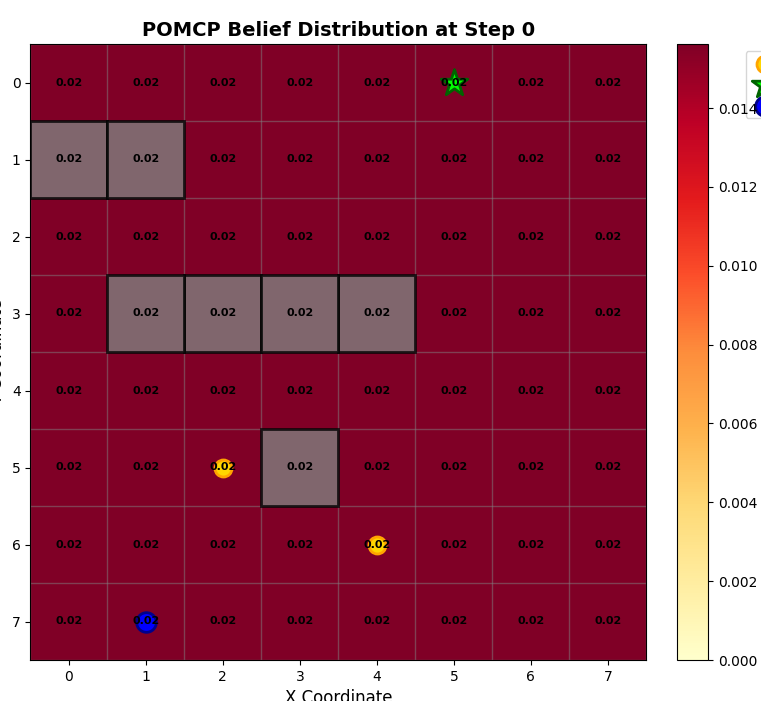
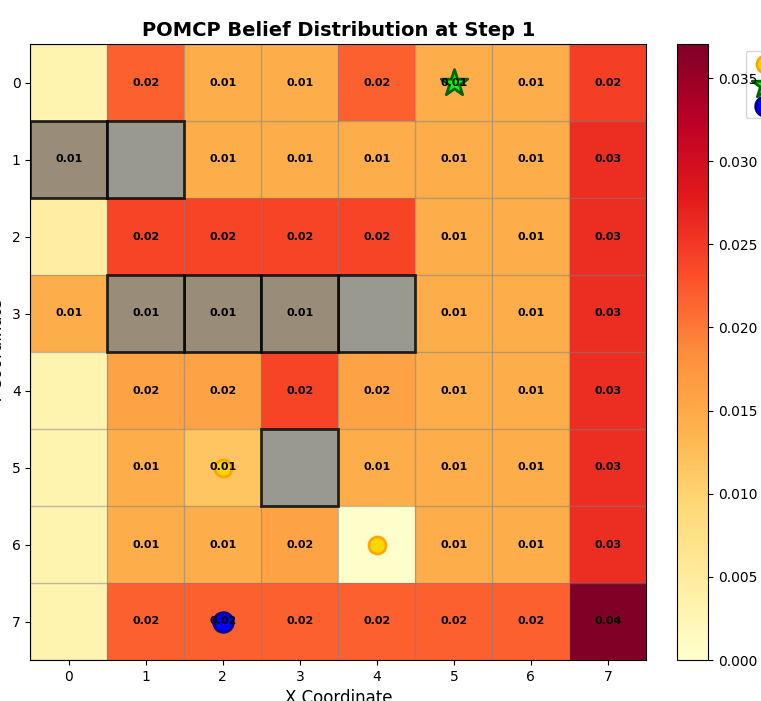
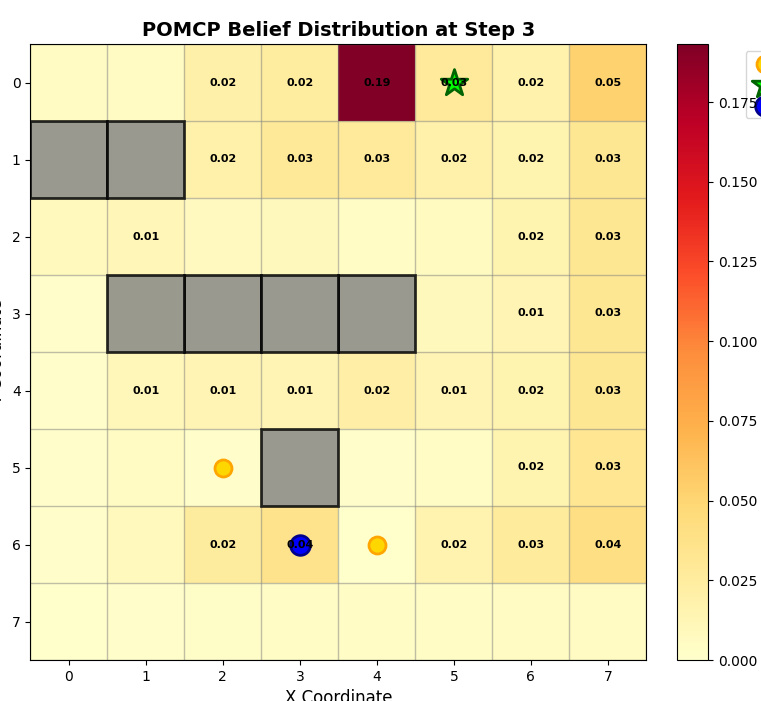

# Evaluacija i skupovi podataka

Podela na **train**, **validation** i **test** skupove ne podrazumeva razdvajanje statičnog skupa podataka,
već **različite konfiguracije okruženja** i **epizoda** kroz koje agent prolazi tokom učenja i evaluacije.

- **Train skup** – obuhvata veći broj generisanih epizoda u različitim mapama lavirinta.
  Agent koristi ove epizode kako bi *naučio politike odlučivanja* koje maksimizuju očekivanu kumulativnu nagradu
  kroz Monte Carlo uzorkovanje i ažuriranje belief-a.

- **Validation skup** – koristi se tokom treniranja za proveru stabilnosti učenja.
  Ove epizode služe za podesavanje hiperparametra **$\gamma$**.

- **Test skup** – predstavlja potpuno nove epizode i konfiguracije lavirinta koje agent ranije nije video.
  Na njima se meri **konačna sposobnost generalizacije** naučene politike i evaluiraju performanse
  pomoću metrika kao što su *stopa uspeha*, *kumulativna nagrada* i *dužina puta*.

In [38]:
from IPython.display import Code, display
display(Code(filename="../src/generator/dataset_generator.py", language="python"))

import os
import json
import hashlib

from src.generator.generate_board import generate_board_from_config


def generate_dataset_split(
        train_size=60,
        val_size=20,
        test_size=20,
        width=8,
        height=8,
        seed=42,
        output_dir="dataset",
):
    """Generate a dataset split into train / val / test folders."""
    splits = {
        "train": train_size,
        "val": val_size,
        "test": test_size,
    }

    os.makedirs(output_dir, exist_ok=True)
    index = {}

    with open("config.json", "r") as f:
        config = json.load(f)

    for split, count in splits.items():
        split_dir = os.path.join(output_dir, split)
        os.makedirs(split_dir, exist_ok=True)
        print(f"\n📁 Generating {count} boards for {split}/ ...")

        created_files = []

        for i in range(count):
            split_hash = int(hashlib.md5(split.encode()).hexdigest(), 16) % 1000
            board_seed = seed + i + split_hash

            prev_dir = os.getcwd()
            os.chdir(split_dir)

            try:
                filename = generate_board_from_config(config, seed=board_seed, board_id=i)
            finally:
                os.chdir(prev_dir)

            created_files.append(os.path.basename(filename))
            print(f"  ✅ [{i + 1}/{count}] {os.path.basename(filename)}")

        index[split] = created_files

    # Save index file
    index_path = os.path.join(output_dir, "index.json")
    with open(index_path, "w") as f:
        json.dump(index, f, indent=4)

    print("\n📦 Dataset generation complete!")
    print(f"📄 Index file saved to: {index_path}")


if __name__ == "__main__":
    generate_dataset_split(train_size=60, val_size=20, test_size=20)

In [41]:
from IPython.display import Code, display
display(Code(filename="../src/generator/generate_board.py", language="python"))

import json
import random


def generate_board_from_config(config, seed=None, board_id=None):
    """
    Generate a board based on a configuration dictionary

    Example config:
    {
        "width": 6,
        "height": 6,
        "wall_density": 0.1,
        "hole_density": 0.05,
        "trap_density": 0.05,
        "coin_density": 0.08,
        "goal_reward": 100.0,
        "wall_penalty": -5.0,
        "hole_penalty": -10.0,
        "trap_penalty": -8.0,
        "coin_reward": 20.0,
        "step_reward": -1,
        "move_probabilities": {"intended":0.8,"left_slip":0.1,"right_slip":0.1},
        "observation_noise": {"sensor_noise":0.3,"sensor_failure":0.1},
        "solver":"pomcp",
        "solver_config": {"max_depth":20,"discount_factor":0.95,"exploration_const":100,"num_sims":1000}
    }
    """
    rng = random.Random(seed)

    width = config.get("width", 6)
    height = config.get("height", 6)

    def rand_pos():
        return [rng.randint(0, width - 1), rng.randint(0, height - 1)]

    # Agent and goal
    agent = rand_pos()
    goal = rand_pos()
    while goal == agent:
        goal = rand_pos()

    def random_positions(count, exclude=None):
        exclude = exclude or set()
        positions = set()
        while len(positions) < count:
            x, y = rand_pos()
            if (x, y) not in exclude:
                positions.add((x, y))
        return [list(p) for p in positions]

    total_cells = width * height
    wall_count = int(total_cells * config.get("wall_density", 0.1))
    hole_count = int(total_cells * config.get("hole_density", 0.05))
    trap_count = int(total_cells * config.get("trap_density", 0.05))
    coin_count = int(total_cells * config.get("coin_density", 0.08))

    occupied = {tuple(agent), tuple(goal)}

    walls = random_positions(wall_count, occupied)
    occupied.update(map(tuple, walls))
    holes = random_positions(hole_count, occupied)
    occupied.update(map(tuple, holes))
    traps = random_positions(trap_count, occupied)
    occupied.update(map(tuple, traps))
    coins = random_positions(coin_count, occupied)
    occupied.update(map(tuple, coins))

    if board_id is not None:
        unique_id = board_id
    elif seed is not None:
        unique_id = seed
    else:
        unique_id = 0

    filename = f"board_{unique_id:04d}.json"

    board = {
        "width": width,
        "height": height,
        "name": f"Board_{unique_id}",
        "description": f"Generated automatically with ID {unique_id}.",
        "agent": agent,
        "goal": {
            "position": goal,
            "reward": config.get("goal_reward", 100.0),
            "terminal": True
        },
        "walls": {
            "positions": walls,
            "penalty": config.get("wall_penalty", -5.0)
        },
        "holes": {
            "positions": holes,
            "penalty": config.get("hole_penalty", -10.0),
            "terminal": True
        },
        "traps": {
            "positions": traps,
            "penalty": config.get("trap_penalty", -8.0),
            "terminal": False
        },
        "coins": {
            "positions": coins,
            "reward": config.get("coin_reward", 20.0)
        },
        "rewards": {
            "step": config.get("step_reward", -1)
        },
        "move_probabilities": config.get("move_probabilities", {"intended": 0.8, "left_slip": 0.1, "right_slip": 0.1}),
        "observation_noise": config.get("observation_noise", {"sensor_noise": 0.3, "sensor_failure": 0.1}),
        "solver": config.get("solver", "pouct"),
        "solver_config": config.get("solver_config",
                                    {"max_depth": 20, "discount_factor": 0.95, "exploration_const": 100,
                                     "num_sims": 1000})
    }

    with open(filename, "w") as f:
        json.dump(board, f, indent=4)

    print(f"✅ Board file created: {filename}")
    return filename

## Evaluacione metrike

Za kvantitativnu procenu performansi agenta korišćene su tri ključne metrike:

### 1. Stopa uspeha (Success Rate)
Predstavlja procenat epizoda u kojima agent uspešno dostiže cilj.
Ova metrika meri **efikasnost i pouzdanost strategije planiranja**.


$\text{Stopa uspeha}$ = $\frac{\text{Broj uspešnih epizoda}}{\text{Ukupan broj epizoda}}$ $\times$ 100$\%$


---

### 2. Cumulative Discounted Reward
Predstavlja ukupnu sumu nagrada koje je agent ostvario tokom epizode, uzimajući u obzir **discount factor**
\($\gamma$ $\in$ (0, 1]\).


$G_t$ = $\sum_{k=0}^{T-t} \gamma^k r_{t+k+1}$


---

### 3. Dužina puta
Mera efikasnosti kretanja agenta — predstavlja broj koraka potrebnih da se stigne do cilja.
Kraći put implicira **bolju optimizaciju planiranja** i **precizniju lokalizaciju belief-a**.

---

Kombinacijom ove tri metrike moguće je dobiti sliku o ponašanju agenta:
- **Stopa uspeha** meri pouzdanost,
- **Zbirna nagrada** meri kvalitet odluka,
- **Dužina puta** procenjuje efikasnost navigacije.


In [43]:
from IPython.display import Code, display
display(Code(filename="../src/utils/metric_utils.py", language="python"))

def calculate_discounted_reward(rewards, gamma=0.9):
    g = 0
    for t, r in enumerate(rewards):
        g += (gamma ** t) * r
    return round(g, 3)


def calculate_total_sum_reward(rewards: list[float]):
    return sum(rewards)

def calculate_path_length(steps):
    return len(steps)

## Evaluacija Agenta

Evaluacija agenta je izvršena na test setu epizoda.
Korišćeni su sledeći koraci:

1. **Osnovna statistika**
   - Broj epizoda: ukupno test slučajeva
   - Stopa uspeha: procenat epizoda u kojima agent stiže do cilja
   - Prosečna dužina puta
   - Prosečna ukupna nagrada
   - Prosečna diskontovana nagrada

2. **Analiza uspeha i neuspeha**
   - Posebna statistika za uspešne i neuspešne epizode:
     - Prosečna dužina puta
     - Prosečna nagrada
     - Prosečna diskontovana nagrada

3. **Distribucije**
   - Histograme za:
     - Dužinu puta (success vs failed)
     - Ukupnu nagradu (success vs failed)
     - Diskauntovanu nagradu (success vs failed)
   - Scatter plot: dužina puta vs ukupna nagrada
   - Boxplot dužine puta po uspešnosti
   - Efikasnost navigacije (nagrada po koraku)
   - Ukupna nagrada i dužina puta po test slučaju

4. **Distribucija akcija**
   - Broj i procenat up/down/left/right akcija tokom svih epizoda

5. **Dodatne vizualizacije**
   - Scatter plot: total reward vs discounted reward
   - Success rate po opsegu dužine puta

6. **Detaljna statistika**
   - Min/Max/Median/Std za dužinu puta, ukupnu i diskauntovanu nagradu
   - Top 5 najboljih i najgorih epizoda
   - Najefikasnije epizode (najkraći uspešni putevi)

### Primeri

- $\gamma$ = 0.4, agent ima manju stopu uspeha, tezi da se vise "gubi" ili "kruži" kada se kreće do cilja. Može se reći da je agent **"kratkovidan"**

```
============================================================
PERFORMANCE EVALUATION SUMMARY
============================================================

Total test cases: 20
Successfully reached goal: 11 (55.0%)
Failed to reach goal: 9 (45.0%)

Average path length: 64.95
Average total reward: 29.85
Average discounted reward: 101.21
============================================================
DETAILED STATISTICS
============================================================

--- Path Length Statistics ---
Min: 0
Max: 128
Median: 32.0
Std Dev: 59.14

--- Total Reward Statistics ---
Min: -1154
Max: 636
Median: 124.00
Std Dev: 497.06

--- Discounted Reward Statistics ---
Min: -84.05
Max: 449.00
Median: 38.42
Std Dev: 146.07
```

![Agent sa 0.4 $\gamma$](maze_performance/maze_performance_04.png)

- $\gamma$ = 0.8, agent i dalje ne zanemaruje manje nagrade, ali isto tako mu nisu fokus. Više je uspešan u pronalaženju cilja, jer mu je discount factor veći (prioritet mu je veći ka daljim nagradama)

```
============================================================
PERFORMANCE EVALUATION SUMMARY
============================================================

Total test cases: 20
Successfully reached goal: 14 (70.0%)
Failed to reach goal: 6 (30.0%)

Average path length: 52.50
Average total reward: 100.35
Average discounted reward: 105.88
============================================================
PERFORMANCE EVALUATION SUMMARY
============================================================

Total test cases: 20
Successfully reached goal: 14 (70.0%)
Failed to reach goal: 6 (30.0%)

Average path length: 52.50
Average total reward: 100.35
Average discounted reward: 105.88
============================================================

--- Successful Cases ---
Average path length: 20.14
Average total reward: 402.14
Average discounted reward: 154.43

--- Failed Cases ---
Average path length: 128.00
Average total reward: -603.83
Average discounted reward: -7.42

--- Action Distribution ---
up: 303 (28.9%)
down: 300 (28.6%)
left: 217 (20.7%)
right: 230 (21.9%)
/home/nikolavelemir/ori-vailed-maze/src/generator/statistics/statistics_utils.py:196: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_by_range = df.groupby('path_range')['reached_goal'].agg(['sum', 'count'])

✓ Visualization saved as 'maze_performance_evaluation.png'

============================================================
DETAILED STATISTICS
============================================================

--- Path Length Statistics ---
Min: 0
Max: 128
Median: 24.0
Std Dev: 54.89

--- Total Reward Statistics ---
Min: -1152
Max: 660
Median: 379.00
Std Dev: 528.15

--- Discounted Reward Statistics ---
Min: -95.32
Max: 403.10
Median: 34.83
Std Dev: 153.99
```

![Agent sa 0.8 $\gamma$](maze_performance/maze_performance_08.png)

- $\gamma$ = 0.95, agent postaje više fokusiran na dugoročne nagrade, odnosno fokusiran na cilj. Iz evaluacije success rate je povećan, mada discounted reward isto može da bude manji, iz razloga sto agent se ne fokusira na novčiće.

```
============================================================
PERFORMANCE EVALUATION SUMMARY
============================================================

Total test cases: 20
Successfully reached goal: 15 (75.0%)
Failed to reach goal: 5 (25.0%)

Average path length: 46.65
Average total reward: 70.15
Average discounted reward: 135.24
============================================================
DETAILED STATISTICS
============================================================

--- Path Length Statistics ---
Min: 0
Max: 128
Median: 20.5
Std Dev: 52.46

--- Total Reward Statistics ---
Min: -1609
Max: 569
Median: 377.00
Std Dev: 597.14

--- Discounted Reward Statistics ---
Min: -23.43
Max: 500.00
Median: 61.39
Std Dev: 157.14

```

![Agent sa 0.95 $\gamma$](maze_performance/maze_performance_095.png)


> Svi grafici su generisani korišćenjem Python skripte koja računa osnovne statistike, histograme, scatter plotove i boxplotove za sve metrike.


## num_sims

Poredjeno je kakav uticaj ima broj simulacija prilikom korišćenja POMCP algoritma. Sledeci konfig ima 750 simulacija, u poređenju sa prethodnim koji su imali 2000 simulacija.
```
============================================================
PERFORMANCE EVALUATION SUMMARY
============================================================

Total test cases: 20
Successfully reached goal: 13 (65.0%)
Failed to reach goal: 7 (35.0%)

Average path length: 52.45
Average total reward: 51.60
Average discounted reward: 152.89
============================================================
DETAILED STATISTICS
============================================================

--- Path Length Statistics ---
Min: 0
Max: 128
Median: 18.0
Std Dev: 57.63

--- Total Reward Statistics ---
Min: -1631
Max: 587
Median: 462.50
Std Dev: 657.47

--- Discounted Reward Statistics ---
Min: -24.10
Max: 394.10
Median: 110.37
Std Dev: 139.40

============================================================
```

![Agent sa 700 simulacija](maze_performance/maze_performance_evaluation_num_sims.png)

Očigledno je da se sa manjim brojem simulacija navigacija pogoršava.


## max_depth

Poredjeno je kakav uticaj ima max_depth prilikom korišćenja POMCP algoritma. Sledeci konfig ima dubinu 10, u poređenju sa prethodnim koji su imali dubinu 40.
![Agent sa 10 max_depth](maze_performance/maze_performance_max_depth.png)



# Zaključak

U ovom radu prikazan je proces obuke i evaluacije agenta koji donosi odluke na osnovu simulacija i nagrada iz okruženja.
Rezultati potvrđuju da uspeh agenta ne zavisi samo od same metode učenja, već i od pažljivo odabranih parametara pomoću kojih agent percipira i vrednuje svoje okruženje. Moguće je napraviti agenta koji je istovremeno efikasan, stabilan i sposoban da uči optimalne strategije kroz interakciju sa okolinom.
